# Symulacja i Analiza Statystyczna Szpitalnego Oddziału Ratunkowego (SOR) z Regresją Wieloraką

Ten program przeprowadza kompleksową analizę działania Szpitalnego Oddziału Ratunkowego (SOR) przy użyciu:
1. **Modelu kolejkowego M/M/c** - symulacja dyskretnych zdarzeń
2. **Analizy statystycznej** - porównanie z teorią kolejek
3. **Regresji wielorakiej** - modelowanie zależności między parametrami a wydajnością

Celem jest zrozumienie dynamiki systemu, oszacowanie kluczowych metryk wydajności oraz budowa modeli regresyjnych do przewidywania wydajności systemu.

### 1. Import niezbędnych bibliotek

Na początek importujemy wszystkie biblioteki potrzebne do symulacji, obliczeń, analizy statystycznej i regresji wielorakiej.

In [463]:
import heapq
import random
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

### 2. Definicja klasy symulatora

Poniższa komórka zawiera pełną klasę SORSimulator_MMc, która jest sercem naszej symulacji. Implementuje ona logikę symulacji dla systemu M/M/c, gdzie pacjenci są obsługiwani w kolejności przybycia (FIFO).

In [464]:
class SORSimulator_MMc:
    """
    Symulator Szpitalnego Oddziału Ratunkowego (SOR) jako klasyczna kolejka M/M/c.
    Pacjenci są obsługiwani w kolejności przybycia (FIFO).
    Implementuje dyskretną symulację zdarzeniową.
    """
    def __init__(self, lambda_rate, mu_rate, c, max_patients):
        if not (lambda_rate > 0 and mu_rate > 0 and c > 0 and max_patients > 0):
            raise ValueError("Parametry lambda, mu, c oraz max_patients muszą być dodatnie.")
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.c = c
        self.max_patients = max_patients

        self.rho = self.lambda_rate / (self.c * self.mu_rate)
        if self.rho >= 1:
            print(f"UWAGA: System jest niestabilny (rho = {self.rho:.3f} >= 1).")

        # Inicjalizacja stanu
        self.clock = 0.0
        self.event_queue = []
        self.doctor_free_times = [0.0] * self.c
        self.waiting_queue = []
        
        self.patient_data = {}
        self.num_patients_treated = 0
        self.next_patient_id = 0
        
        self.generated_interarrival_times = []
        self.generated_treatment_times = []

    def _generate_exponential_time(self, rate):
        return random.expovariate(rate)

    def _schedule_event(self, time, event_type, data):
        heapq.heappush(self.event_queue, (time, event_type, data))

    def run(self):
        """Główna pętla symulacji."""
        initial_arrival_time = self._generate_exponential_time(self.lambda_rate)
        self.generated_interarrival_times.append(initial_arrival_time)
        self._schedule_event(initial_arrival_time, "ARRIVAL", {'patient_id': self.next_patient_id})
        self.next_patient_id += 1

        while self.num_patients_treated < self.max_patients:
            if not self.event_queue:
                print("Błąd: Kolejka zdarzeń pusta przed obsłużeniem wszystkich pacjentów.")
                break
            
            event_time, event_type, data = heapq.heappop(self.event_queue)
            self.clock = event_time
            
            if event_type == "ARRIVAL":
                self._handle_arrival(data['patient_id'])
            elif event_type == "DEPARTURE":
                self._handle_departure(data['patient_id'], data['doctor_id'])

    def _handle_arrival(self, patient_id):
        self.patient_data[patient_id] = {'arrival_time': self.clock}

        if self.next_patient_id < self.max_patients:
            interarrival_time = self._generate_exponential_time(self.lambda_rate)
            self._schedule_event(self.clock + interarrival_time, "ARRIVAL", {'patient_id': self.next_patient_id})
            self.next_patient_id += 1
            self.generated_interarrival_times.append(interarrival_time)
        
        # Sprawdź czy JAKIKOLWIEK lekarz jest dostępny TERAZ
        available_doctors = [i for i, free_time in enumerate(self.doctor_free_times) 
                            if free_time <= self.clock]
        
        if available_doctors:
            # Wybierz pierwszego dostępnego lekarza
            doctor_id = available_doctors[0]
            self._start_treatment(patient_id, doctor_id)
        else:
            # Wszyscy lekarze są zajęci - pacjent czeka
            self.waiting_queue.append(patient_id)

    def _handle_departure(self, patient_id, doctor_id):
        self.patient_data[patient_id]['departure_time'] = self.clock
        self.num_patients_treated += 1
        
        if self.waiting_queue:
            next_patient_id = self.waiting_queue.pop(0)
            self._start_treatment(next_patient_id, doctor_id)

    def _start_treatment(self, patient_id, doctor_id):
        # Leczenie może rozpocząć się najwcześniej gdy lekarz będzie wolny
        actual_start_time = max(self.clock, self.doctor_free_times[doctor_id])
        
        self.patient_data[patient_id]['treatment_start_time'] = actual_start_time

        treatment_time = self._generate_exponential_time(self.mu_rate)
        self.generated_treatment_times.append(treatment_time)
        departure_time = actual_start_time + treatment_time
        self.doctor_free_times[doctor_id] = departure_time
        self._schedule_event(departure_time, "DEPARTURE", {'patient_id': patient_id, 'doctor_id': doctor_id})

    def calculate_performance_metrics(self):
        wait_times = []
        system_times = []
        
        for data in self.patient_data.values():
            if 'departure_time' in data and 'treatment_start_time' in data:
                wait_times.append(data['treatment_start_time'] - data['arrival_time'])
                system_times.append(data['departure_time'] - data['arrival_time'])
        
        if not wait_times:
            return None
        return {
            "mean_wait_time": np.mean(wait_times),
            "mean_system_time": np.mean(system_times),
            "all_wait_times": wait_times
        }

### 3. Funkcje pomocnicze do analizy

Tutaj definiujemy funkcje, które obliczą wartości teoretyczne dla modelu M/M/c oraz przeprowadzą wnioskowanie statystyczne.

In [465]:
def calculate_theoretical_values(lambda_rate, mu_rate, c):
    """Oblicza teoretyczne wartości dla kolejki M/M/c."""
    rho = lambda_rate / (c * mu_rate)
    if rho >= 1:
        return {"Wq": float('inf'), "Lq": float('inf'), "P0": 0, "rho": rho}
    sum_part = sum([(c * rho)**n / math.factorial(n) for n in range(c)])
    last_part = (c * rho)**c / (math.factorial(c) * (1 - rho))
    P0 = 1 / (sum_part + last_part)
    Lq = (P0 * (lambda_rate / mu_rate)**c * rho) / (math.factorial(c) * (1 - rho)**2)
    Wq = Lq / lambda_rate
    W = Wq + (1 / mu_rate)

    print("\n" + "="*50)
    print("      TEORETYCZNE WARTOŚCI dla M/M/c")
    print("="*50)
    print(f"      Rho (obciążenie systemu): {rho:.4f}")
    print(f"      Wq (średni czas oczekiwania w kolejce): {Wq:.4f} godzin ({Wq * 60:.2f} minut)")
    print(f"      Lq (średnia liczba pacjentów w kolejce): {Lq:.4f}")
    print(f"      W (średni czas w systemie): {W:.4f} godzin ({W * 60:.2f} minut)")
    print(f"      P0 (prawdopodobieństwo, że system jest pusty): {P0:.4f}")

    return {"Wq": Wq, "Lq": Lq, "W": W, "P0": P0, "rho": rho}

def statistical_inference(simulator, sim_results, theoretical_values):
    """Przeprowadza i prezentuje wyniki wnioskowania statystycznego."""
    print("\n" + "="*50)
    print("      WNIOSKOWANIE STATYSTYCZNE")
    print("="*50)

    print("\n1. Testy Kołmogorowa-Smirnowa dla założeń wejściowych")
    ks_arrival = stats.kstest(simulator.generated_interarrival_times, 'expon', args=(0, 1/simulator.lambda_rate))
    print(f"\n   a) Test K-S dla czasów między przybyciami (lambda={simulator.lambda_rate}):")
    print(f"      Statystyka D = {ks_arrival.statistic:.4f}, p-wartość = {ks_arrival.pvalue:.4f}")
    if ks_arrival.pvalue > 0.05:
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0.")
    else:
        print("      Wniosek: ODRZUCONO H0.")

    ks_service = stats.kstest(simulator.generated_treatment_times, 'expon', args=(0, 1/simulator.mu_rate))
    print(f"\n   b) Test K-S dla czasów leczenia (mu={simulator.mu_rate}):")
    print(f"      Statystyka D = {ks_service.statistic:.4f}, p-wartość = {ks_service.pvalue:.4f}")
    if ks_service.pvalue > 0.05:
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0.")
    else:
        print("      Wniosek: ODRZUCONO H0.")

    print("\n2. Porównanie wyników symulacji z modelem teoretycznym")
    mean_wait_sim = sim_results['mean_wait_time']
    theoretical_wq = theoretical_values['Wq']
    
    print("\n   a) Test t-Studenta dla średniego czasu oczekiwania (Wq)")
    print(f"      H0: Średnia z symulacji ({mean_wait_sim:.4f}) jest równa wartości teoretycznej ({theoretical_wq:.4f}).")
    ttest_result = stats.ttest_1samp(a=sim_results['all_wait_times'], popmean=theoretical_wq)
    print(f"      Statystyka t = {ttest_result.statistic:.4f}, p-wartość = {ttest_result.pvalue:.4f}")
    if ttest_result.pvalue > 0.05: 
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0. Wyniki zgodne z teorią.")
    else:
        print("      Wniosek: ODRZUCONO H0. Średnie różnią się statystycznie istotnie.")
        
    print("\n   b) 95% Przedział ufności dla średniego czasu oczekiwania (Wq)")
    confidence_interval = stats.t.interval(0.95, len(sim_results['all_wait_times'])-1, loc=mean_wait_sim, scale=stats.sem(sim_results['all_wait_times']))
    print(f"      Obliczony przedział: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")
    print(f"      Wartość teoretyczna: {theoretical_wq:.4f}")
    if confidence_interval[0] <= theoretical_wq <= confidence_interval[1]:
        print("      Wniosek: OK. Wartość teoretyczna mieści się w przedziale ufności.")
    else:
        print("      Wniosek: Wartość teoretyczna POZA przedziałem ufności.")


    # alternatywa dla T Studenta
    print("\n   c) Test Mann-Whitney")
    mw_result = stats.mannwhitneyu(
        sim_results['all_wait_times'], 
        theoretical_wq, 
        alternative='two-sided'
    )
    print(f"      Statystyka U = {mw_result.statistic:.4f}, p-wartość = {mw_result.pvalue:.4f}")
    if mw_result.pvalue > 0.05: 
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0. Wyniki zgodne z teorią.")
    else:
        print("      Wniosek: ODRZUCONO H0. Rozkłady różnią się statystycznie istotnie.")

### 4. Klasa do analizy regresji wielorakiej

Ta sekcja zawiera klasę SORRegressionAnalysis, która przeprowadza kompleksową analizę regresji wielorakiej dla systemu SOR.

In [466]:
class SORRegressionAnalysis:
    """
    Klasa do przeprowadzania analizy regresji wielorakiej 
    dla systemu Szpitalnego Oddziału Ratunkowego
    """
    
    def __init__(self):
        self.data = None
        self.models = {}
        self.results = {}
        
    def generate_experimental_data(self, n_experiments=150):
        """
        Generuje dane eksperymentalne poprzez uruchomienie wielu symulacji
        z różnymi parametrami wejściowymi
        """
        print("Generowanie danych eksperymentalnych...")
        print("=" * 60)
        
        # Definiowanie zakresów parametrów
        lambda_range = np.linspace(2.0, 7.0, 15)  # Intensywność przybyć
        mu_range = np.linspace(1.5, 3.5, 12)      # Intensywność obsługi
        c_range = [2, 3, 4, 5]                    # Liczba lekarzy
        
        data_list = []
        experiment_count = 0
        
        for lambda_rate in lambda_range:
            for mu_rate in mu_range:
                for c_doctors in c_range:
                    # Sprawdź stabilność systemu
                    rho = lambda_rate / (c_doctors * mu_rate)
                    if rho >= 0.95:  # Pomijaj niestabilne systemy
                        continue
                    
                    try:
                        # Uruchomia symulację
                        simulator = SORSimulator_MMc(
                            lambda_rate=lambda_rate,
                            mu_rate=mu_rate, 
                            c=c_doctors,
                            max_patients=1500
                        )
                        simulator.run()
                        results = simulator.calculate_performance_metrics()
                        
                        if results:
                            # Oblicz dodatkowe metryki
                            theoretical = calculate_theoretical_values(
                                lambda_rate, mu_rate, c_doctors
                            )
                            
                            # Dodaj dane do listy
                            data_list.append({
                                # Zmienne niezależne
                                'lambda': lambda_rate,
                                'mu': mu_rate,
                                'c': c_doctors,
                                'rho': rho,
                                'arrival_rate_per_doctor': lambda_rate / c_doctors,
                                'service_capacity': c_doctors * mu_rate,
                                'utilization': lambda_rate / (c_doctors * mu_rate),
                                
                                # Zmienne zależne (metryki wydajności)
                                'mean_wait_time': results['mean_wait_time'],
                                'mean_system_time': results['mean_system_time'],
                                'mean_wait_time_minutes': results['mean_wait_time'] * 60,
                                'mean_system_time_minutes': results['mean_system_time'] * 60,
                                
                                # Wartości teoretyczne dla porównania
                                'theoretical_wq': theoretical['Wq'],
                                'theoretical_w': theoretical['W'],
                                'theoretical_lq': theoretical['Lq'],
                                
                                # Różnice między symulacją a teorią
                                'diff_wq': results['mean_wait_time'] - theoretical['Wq'],
                                'diff_w': results['mean_system_time'] - theoretical['W'],
                                'relative_error_wq': abs(results['mean_wait_time'] - theoretical['Wq']) / theoretical['Wq'] * 100
                            })
                            
                            experiment_count += 1
                            if experiment_count % 25 == 0:
                                print(f"   Ukończono {experiment_count} eksperymentów...")
                                
                    except Exception as e:
                        continue
                        
                    if experiment_count >= n_experiments:
                        break
                if experiment_count >= n_experiments:
                    break
            if experiment_count >= n_experiments:
                break
        
        self.data = pd.DataFrame(data_list)
        print(f"\n✅ Wygenerowano {len(self.data)} eksperymentów")
        print(f"📊 Kształt danych: {self.data.shape}")
        return self.data
    
    def build_regression_models(self):
        """
        Buduje różne modele regresji wielorakiej
        """
        if self.data is None:
            raise ValueError("Najpierw wygeneruj dane eksperymentalne!")
            
        print("\n🔧 Budowanie modeli regresji wielorakiej...")
        print("=" * 60)
        
        # Definicja zmiennych niezależnych i zależnych
        feature_sets = {
            'basic': ['lambda', 'mu', 'c'],
            'extended': ['lambda', 'mu', 'c', 'rho', 'utilization'],
            'engineered': ['lambda', 'mu', 'c', 'arrival_rate_per_doctor', 'service_capacity']
        }
        
        target_variables = {
            'wait_time_minutes': 'mean_wait_time_minutes',
            'system_time_minutes': 'mean_system_time_minutes'
        }
        
        for target_name, target_var in target_variables.items():
            print(f"\n📈 Modelowanie: {target_name}")
            
            for feature_name, features in feature_sets.items():
                print(f"   🔹 Zestaw cech: {feature_name}")
                
                X = self.data[features]
                y = self.data[target_var]
                
                # Podział na zbiór treningowy i testowy
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )
                
                # Model liniowy
                model_linear = LinearRegression()
                model_linear.fit(X_train, y_train)
                y_pred_linear = model_linear.predict(X_test)
                
                # Model z cechami wielomianowymi (stopień 2)
                poly_features = PolynomialFeatures(degree=2, include_bias=False)
                X_train_poly = poly_features.fit_transform(X_train)
                X_test_poly = poly_features.transform(X_test)
                
                model_poly = LinearRegression()
                model_poly.fit(X_train_poly, y_train)
                y_pred_poly = model_poly.predict(X_test_poly)
                
                # Obliczamy metryki
                metrics_linear = self._calculate_metrics(y_test, y_pred_linear)
                metrics_poly = self._calculate_metrics(y_test, y_pred_poly)
                
                # Zapisz modele i wyniki
                model_key = f"{target_name}_{feature_name}"
                self.models[f"{model_key}_linear"] = {
                    'model': model_linear,
                    'features': features,
                    'metrics': metrics_linear,
                    'predictions': y_pred_linear,
                    'y_test': y_test
                }
                
                self.models[f"{model_key}_poly"] = {
                    'model': model_poly,
                    'poly_features': poly_features,
                    'features': features,
                    'metrics': metrics_poly,
                    'predictions': y_pred_poly,
                    'y_test': y_test
                }
                
                print(f"      Linear R²: {metrics_linear['r2']:.4f}, RMSE: {metrics_linear['rmse']:.4f}")
                print(f"      Poly R²:   {metrics_poly['r2']:.4f}, RMSE: {metrics_poly['rmse']:.4f}")
    
    def _calculate_metrics(self, y_true, y_pred):
        """Oblicza metryki oceny modelu"""
        return {
            'r2': r2_score(y_true, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'mape': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        }
    
    def analyze_model_performance(self):
        """
        Szczegółowa analiza wydajności modeli regresji
        """
        print("\n📊 ANALIZA WYDAJNOŚCI MODELI REGRESJI")
        print("=" * 60)
        
        # Znajdź najlepsze modele
        best_models = {}
        for target in ['wait_time_minutes', 'system_time_minutes']:
            best_r2 = -np.inf
            best_model_key = None
            
            for key, model_data in self.models.items():
                if target in key:
                    if model_data['metrics']['r2'] > best_r2:
                        best_r2 = model_data['metrics']['r2']
                        best_model_key = key
            
            best_models[target] = best_model_key
        
        # Analiza najlepszych modeli
        for target, best_key in best_models.items():
            print(f"\n🏆 NAJLEPSZY MODEL DLA: {target.upper()}")
            print("-" * 40)
            
            model_data = self.models[best_key]
            metrics = model_data['metrics']
            
            print(f"Model: {best_key}")
            print(f"R² (współczynnik determinacji): {metrics['r2']:.4f}")
            print(f"RMSE (błąd średniokwadratowy): {metrics['rmse']:.4f}")
            print(f"MAE (średni błąd bezwzględny): {metrics['mae']:.4f}")
            print(f"MAPE (średni błąd procentowy): {metrics['mape']:.2f}%")
            
            # Interpretacja R²
            if metrics['r2'] >= 0.9:
                print("✅ Bardzo dobre dopasowanie modelu (R² ≥ 0.9)")
            elif metrics['r2'] >= 0.7:
                print("✅ Dobre dopasowanie modelu (0.7 ≤ R² < 0.9)")
            elif metrics['r2'] >= 0.5:
                print("⚠️  Umiarkowane dopasowanie modelu (0.5 ≤ R² < 0.7)")
            else:
                print("❌ Słabe dopasowanie modelu (R² < 0.5)")
            
            # Analiza reszt
            residuals = model_data['y_test'] - model_data['predictions']
            
            # Test normalności reszt (Shapiro-Wilk)
            if len(residuals) <= 5000:  # Shapiro-Wilk ma ograniczenie
                stat, p_value = stats.shapiro(residuals)
                print(f"\nTest normalności reszt (Shapiro-Wilk):")
                print(f"Statystyka: {stat:.4f}, p-wartość: {p_value:.4f}")
                if p_value > 0.05:
                    print("✅ Reszty mają rozkład normalny (p > 0.05)")
                else:
                    print("⚠️  Reszty mogą nie mieć rozkładu normalnego (p ≤ 0.05)")
    
    def plot_regression_results(self):
        """
        Tworzy wykresy analizujące wyniki regresji
        """
        if not self.models:
            raise ValueError("Najpierw zbuduj modele regresji!")
        
        # Znajdź najlepsze modele
        best_models = {}
        for target in ['wait_time_minutes', 'system_time_minutes']:
            best_r2 = -np.inf
            best_model_key = None
            
            for key, model_data in self.models.items():
                if target in key:
                    if model_data['metrics']['r2'] > best_r2:
                        best_r2 = model_data['metrics']['r2']
                        best_model_key = key
            
            best_models[target] = best_model_key
        
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Analiza Modeli Regresji Wielorakiej - System SOR', fontsize=16, fontweight='bold')
        
        for i, (target, best_key) in enumerate(best_models.items()):
            model_data = self.models[best_key]
            y_test = model_data['y_test']
            y_pred = model_data['predictions']
            residuals = y_test - y_pred
            
            # 1. Wykres rzeczywiste vs przewidywane
            axes[i, 0].scatter(y_test, y_pred, alpha=0.6, s=30)
            axes[i, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
            axes[i, 0].set_xlabel('Wartości rzeczywiste')
            axes[i, 0].set_ylabel('Wartości przewidywane')
            axes[i, 0].set_title(f'{target}: Rzeczywiste vs Przewidywane\nR² = {model_data["metrics"]["r2"]:.4f}')
            axes[i, 0].grid(True, alpha=0.3)
            
            # 2. Wykres reszt
            axes[i, 1].scatter(y_pred, residuals, alpha=0.6, s=30)
            axes[i, 1].axhline(y=0, color='r', linestyle='--')
            axes[i, 1].set_xlabel('Wartości przewidywane')
            axes[i, 1].set_ylabel('Reszty')
            axes[i, 1].set_title(f'{target}: Analiza reszt')
            axes[i, 1].grid(True, alpha=0.3)
            
            # 3. Q-Q plot normalności reszt
            stats.probplot(residuals, dist="norm", plot=axes[i, 2])
            axes[i, 2].set_title(f'{target}: Q-Q Plot reszt')
            axes[i, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Dodatkowy wykres: porównanie wszystkich modeli
        self._plot_model_comparison()
    
    def _plot_model_comparison(self):
        """Porównuje wszystkie modele"""
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Przygotuj dane do porównania
        model_names = []
        r2_scores = []
        rmse_scores = []
        
        for key, model_data in self.models.items():
            model_names.append(key.replace('_', '\n'))
            r2_scores.append(model_data['metrics']['r2'])
            rmse_scores.append(model_data['metrics']['rmse'])
        
        # Wykres R²
        bars1 = ax1.bar(range(len(model_names)), r2_scores, color='skyblue', alpha=0.8)
        ax1.set_xlabel('Modele')
        ax1.set_ylabel('R² Score')
        ax1.set_title('Porównanie współczynnika determinacji R²')
        ax1.set_xticks(range(len(model_names)))
        ax1.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=0.9, color='green', linestyle='--', alpha=0.7, label='Bardzo dobre (R²≥0.9)')
        ax1.axhline(y=0.7, color='orange', linestyle='--', alpha=0.7, label='Dobre (R²≥0.7)')
        ax1.legend()
        
        # Dodaj wartości na słupkach
        for bar, score in zip(bars1, r2_scores):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontsize=8)
        
        # Wykres RMSE
        bars2 = ax2.bar(range(len(model_names)), rmse_scores, color='lightcoral', alpha=0.8)
        ax2.set_xlabel('Modele')
        ax2.set_ylabel('RMSE')
        ax2.set_title('Porównanie błędu średniokwadratowego RMSE')
        ax2.set_xticks(range(len(model_names)))
        ax2.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax2.grid(True, alpha=0.3)
        
        # Dodaj wartości na słupkach
        for bar, score in zip(bars2, rmse_scores):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + max(rmse_scores)*0.01,
                    f'{score:.2f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
    
    def feature_importance_analysis(self):
        """
        Analiza ważności cech w modelach liniowych
        """
        print("\n🔍 ANALIZA WAŻNOŚCI CECH")
        print("=" * 60)
        
        for target in ['wait_time_minutes', 'system_time_minutes']:
            print(f"\n📊 Analiza dla: {target}")
            print("-" * 30)
            
            # Znajdź model liniowy z extended features
            model_key = f"{target}_extended_linear"
            if model_key in self.models:
                model_data = self.models[model_key]
                model = model_data['model']
                features = model_data['features']
                
                # Współczynniki regresji
                coefficients = model.coef_
                intercept = model.intercept_
                
                print(f"Wyraz wolny (intercept): {intercept:.4f}")
                print("\nWspółczynniki regresji:")
                
                # Sortuj cechy według wartości bezwzględnej współczynników
                feature_importance = list(zip(features, coefficients))
                feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
                
                for feature, coef in feature_importance:
                    print(f"  {feature:20s}: {coef:8.4f}")
                    
                # Interpretacja współczynników
                print("\nInterpretacja (przy założeniu ceteris paribus):")
                for feature, coef in feature_importance[:3]:  # Top 3
                    if coef > 0:
                        direction = "zwiększa"
                    else:
                        direction = "zmniejsza" 
                    print(f"  • Wzrost {feature} o 1 jednostkę {direction} {target} o {abs(coef):.4f}")

### 5. Parametry wejściowe i uruchomienie podstawowej symulacji

W tej części definiujemy parametry wejściowe, uruchamiamy podstawową symulację i wywołujemy funkcje analityczne.

In [467]:
# --- Parametry wejściowe ---
LAMBDA_RATE = 5.0    # Średnio 5 pacjentów przybywa na godzinę
MU_RATE = 2.0        # Jeden lekarz obsługuje średnio 2 pacjentów na godzinę
C_DOCTORS = 3        # 3 lekarzy na dyżurze
MAX_PATIENTS = 5000  # Liczba pacjentów do zasymulowania

print("\n" + "="*50)
print("      PARAMETRY SYSTEMU SOR")
print("="*50)
print(f"Intensywność przybyć (λ): {LAMBDA_RATE} pacjentów/godz")
print(f"Intensywność obsługi (μ): {MU_RATE} pacjentów/godz/lekarz")
print(f"Liczba lekarzy (c): {C_DOCTORS}")
print(f"Liczba pacjentów do symulacji: {MAX_PATIENTS}")


      PARAMETRY SYSTEMU SOR
Intensywność przybyć (λ): 5.0 pacjentów/godz
Intensywność obsługi (μ): 2.0 pacjentów/godz/lekarz
Liczba lekarzy (c): 3
Liczba pacjentów do symulacji: 5000


In [468]:
# Obliczenie wartości teoretycznych
theoretical_vals = calculate_theoretical_values(LAMBDA_RATE, MU_RATE, C_DOCTORS)

print("\n" + "="*50)
print("      TEORETYCZNE WARTOŚCI dla M/M/c")
print("="*50)
print(f"      Rho (obciążenie systemu): {theoretical_vals['rho']:.4f}")
print(f"      Wq (średni czas oczekiwania w kolejce): {theoretical_vals['Wq']:.4f} godzin ({theoretical_vals['Wq'] * 60:.2f} minut)")
print(f"      Lq (średnia liczba pacjentów w kolejce): {theoretical_vals['Lq']:.4f}")
print(f"      W (średni czas w systemie): {theoretical_vals['W']:.4f} godzin ({theoretical_vals['W'] * 60:.2f} minut)")
print(f"      P0 (prawdopodobieństwo, że system jest pusty): {theoretical_vals['P0']:.4f}")


      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.8333
      Wq (średni czas oczekiwania w kolejce): 0.7022 godzin (42.13 minut)
      Lq (średnia liczba pacjentów w kolejce): 3.5112
      W (średni czas w systemie): 1.2022 godzin (72.13 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.0449

      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.8333
      Wq (średni czas oczekiwania w kolejce): 0.7022 godzin (42.13 minut)
      Lq (średnia liczba pacjentów w kolejce): 3.5112
      W (średni czas w systemie): 1.2022 godzin (72.13 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.0449


In [469]:
# Uruchomienie podstawowej symulacji
print("\n" + "="*50)
print("      URUCHAMIANIE SYMULACJI SOR (model M/M/c FIFO)")
print("="*50)

simulator = SORSimulator_MMc(LAMBDA_RATE, MU_RATE, C_DOCTORS, MAX_PATIENTS)
simulator.run()
sim_results = simulator.calculate_performance_metrics()

if sim_results:
    print(f"      --- Zakończono symulację. Obsłużono {simulator.num_patients_treated} pacjentów. ---")
    print("\n      --- Wyniki z symulacji (model M/M/c FIFO) ---")
    wq_sim_h = sim_results['mean_wait_time']
    w_sim_h = sim_results['mean_system_time']
    print(f"            Średni czas oczekiwania na lekarza (Wq): {wq_sim_h:.4f} godzin ({wq_sim_h*60:.2f} minut)")
    print(f"            Średni czas pobytu na SOR (W):          {w_sim_h:.4f} godzin ({w_sim_h*60:.2f} minut)")


      URUCHAMIANIE SYMULACJI SOR (model M/M/c FIFO)
      --- Zakończono symulację. Obsłużono 5000 pacjentów. ---

      --- Wyniki z symulacji (model M/M/c FIFO) ---
            Średni czas oczekiwania na lekarza (Wq): 0.5589 godzin (33.53 minut)
            Średni czas pobytu na SOR (W):          1.0551 godzin (63.31 minut)


In [470]:
# --- Wnioskowanie statystyczne ---
statistical_inference(simulator, sim_results, theoretical_vals)


      WNIOSKOWANIE STATYSTYCZNE

1. Testy Kołmogorowa-Smirnowa dla założeń wejściowych

   a) Test K-S dla czasów między przybyciami (lambda=5.0):
      Statystyka D = 0.0087, p-wartość = 0.8452
      Wniosek: OK. Brak podstaw do odrzucenia H0.

   b) Test K-S dla czasów leczenia (mu=2.0):
      Statystyka D = 0.0167, p-wartość = 0.1235
      Wniosek: OK. Brak podstaw do odrzucenia H0.

2. Porównanie wyników symulacji z modelem teoretycznym

   a) Test t-Studenta dla średniego czasu oczekiwania (Wq)
      H0: Średnia z symulacji (0.5589) jest równa wartości teoretycznej (0.7022).
      Statystyka t = -14.0024, p-wartość = 0.0000
      Wniosek: ODRZUCONO H0. Średnie różnią się statystycznie istotnie.

   b) 95% Przedział ufności dla średniego czasu oczekiwania (Wq)
      Obliczony przedział: (0.5388, 0.5789)
      Wartość teoretyczna: 0.7022
      Wniosek: Wartość teoretyczna POZA przedziałem ufności.

   c) Test Mann-Whitney
      Statystyka U = 1545.0000, p-wartość = 0.5012
      Wni

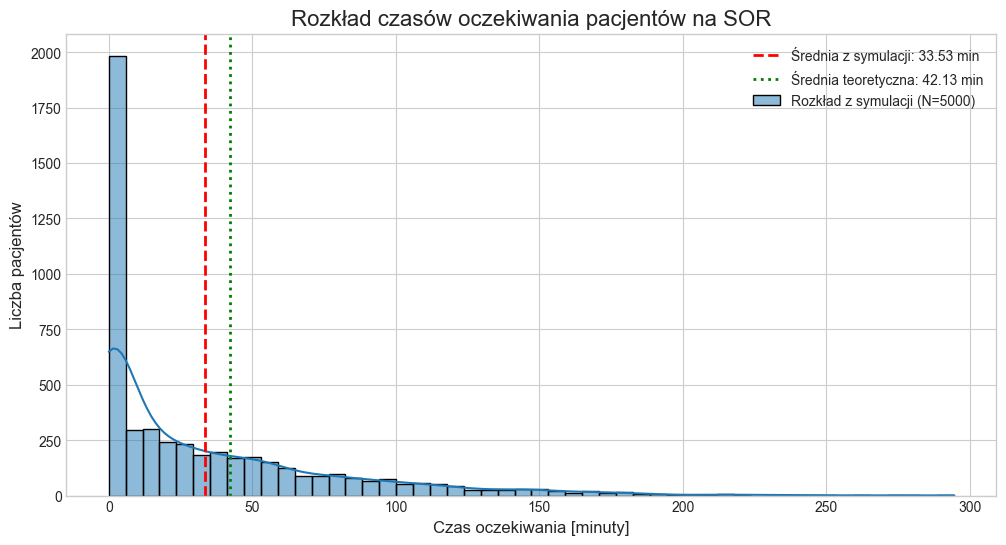

In [471]:
# Wykres rozkładu czasów oczekiwania
if 'sim_results' in locals() and sim_results:
    wait_times_minutes = [t * 60 for t in sim_results['all_wait_times']]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    # Histogram
    sns.histplot(wait_times_minutes, bins=50, kde=True, ax=ax,
                 label=f"Rozkład z symulacji (N={len(wait_times_minutes)})")
    
    # Linie dla wartości średnich
    mean_sim_min = sim_results['mean_wait_time'] * 60
    mean_th_min = theoretical_vals['Wq'] * 60
    
    ax.axvline(mean_sim_min, color='red', linestyle='--', linewidth=2,
               label=f'Średnia z symulacji: {mean_sim_min:.2f} min')
    ax.axvline(mean_th_min, color='green', linestyle=':', linewidth=2,
               label=f'Średnia teoretyczna: {mean_th_min:.2f} min')

    ax.set_title('Rozkład czasów oczekiwania pacjentów na SOR', fontsize=16)
    ax.set_xlabel('Czas oczekiwania [minuty]', fontsize=12)
    ax.set_ylabel('Liczba pacjentów', fontsize=12)
    ax.legend()
    plt.show()

### 6. Analiza regresji wielorakiej

W tej sekcji przeprowadzamy główną analizę regresji wielorakiej, aby zbadać zależności między parametrami systemu a metrykami wydajności oraz ocenić stopień dopasowania modeli regresyjnych.

In [472]:
print("\n" + "="*70)
print("      ANALIZA REGRESJI WIELORAKIEJ SYSTEMU SOR")
print("="*70)

# Inicjalizacja analizatora
analyzer = SORRegressionAnalysis()

# Generowanie danych eksperymentalnych
experimental_data = analyzer.generate_experimental_data(n_experiments=120)


      ANALIZA REGRESJI WIELORAKIEJ SYSTEMU SOR
Generowanie danych eksperymentalnych...

      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.6667
      Wq (średni czas oczekiwania w kolejce): 0.5333 godzin (32.00 minut)
      Lq (średnia liczba pacjentów w kolejce): 1.0667
      W (średni czas w systemie): 1.2000 godzin (72.00 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.2000

      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.4444
      Wq (średni czas oczekiwania w kolejce): 0.0723 godzin (4.34 minut)
      Lq (średnia liczba pacjentów w kolejce): 0.1446
      W (średni czas w systemie): 0.7390 godzin (44.34 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.2542

      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.3333
      Wq (średni czas oczekiwania w kolejce): 0.0129 godzin (0.78 minut)
      Lq (średnia liczba pacjentów w kolejce): 0.0259
      W (średni czas w systemie): 0.6796 godzin (40.78 

In [473]:
# Wyświetlenie podstawowych statystyk danych
print("\n📈 PODSTAWOWE STATYSTYKI DANYCH EKSPERYMENTALNYCH")
print("="*60)
print(experimental_data[['lambda', 'mu', 'c', 'mean_wait_time_minutes', 'mean_system_time_minutes']].describe())


📈 PODSTAWOWE STATYSTYKI DANYCH EKSPERYMENTALNYCH
           lambda          mu           c  mean_wait_time_minutes  \
count  120.000000  120.000000  120.000000              120.000000   
mean     2.285714    2.390909    3.500000                5.382170   
std      0.268382    0.620684    1.122722               14.755704   
min      2.000000    1.500000    2.000000                0.000000   
25%      2.000000    1.863636    2.750000                0.064159   
50%      2.357143    2.318182    3.500000                0.479087   
75%      2.357143    2.954545    4.250000                3.269682   
max      2.714286    3.500000    5.000000              102.082541   

       mean_system_time_minutes  
count                120.000000  
mean                  32.304823  
std                   18.562117  
min                   16.251328  
25%                   21.684724  
50%                   27.253657  
75%                   36.205884  
max                  137.878648  


In [474]:
# Budowanie modeli regresji wielorakiej
analyzer.build_regression_models()

# Szczegółowa analiza wydajności modeli
analyzer.analyze_model_performance()


🔧 Budowanie modeli regresji wielorakiej...

📈 Modelowanie: wait_time_minutes
   🔹 Zestaw cech: basic
      Linear R²: 0.4313, RMSE: 8.7605
      Poly R²:   0.6568, RMSE: 6.8052
   🔹 Zestaw cech: extended
      Linear R²: 0.8154, RMSE: 4.9905
      Poly R²:   0.9603, RMSE: 2.3153
   🔹 Zestaw cech: engineered
      Linear R²: 0.5952, RMSE: 7.3912
      Poly R²:   0.6883, RMSE: 6.4851

📈 Modelowanie: system_time_minutes
   🔹 Zestaw cech: basic
      Linear R²: 0.6614, RMSE: 9.6285
      Poly R²:   0.8192, RMSE: 7.0352
   🔹 Zestaw cech: extended
      Linear R²: 0.9046, RMSE: 5.1121
      Poly R²:   0.9799, RMSE: 2.3455
   🔹 Zestaw cech: engineered
      Linear R²: 0.7384, RMSE: 8.4627
      Poly R²:   0.8400, RMSE: 6.6193

📊 ANALIZA WYDAJNOŚCI MODELI REGRESJI

🏆 NAJLEPSZY MODEL DLA: WAIT_TIME_MINUTES
----------------------------------------
Model: wait_time_minutes_extended_poly
R² (współczynnik determinacji): 0.9603
RMSE (błąd średniokwadratowy): 2.3153
MAE (średni błąd bezwzględny): 1.

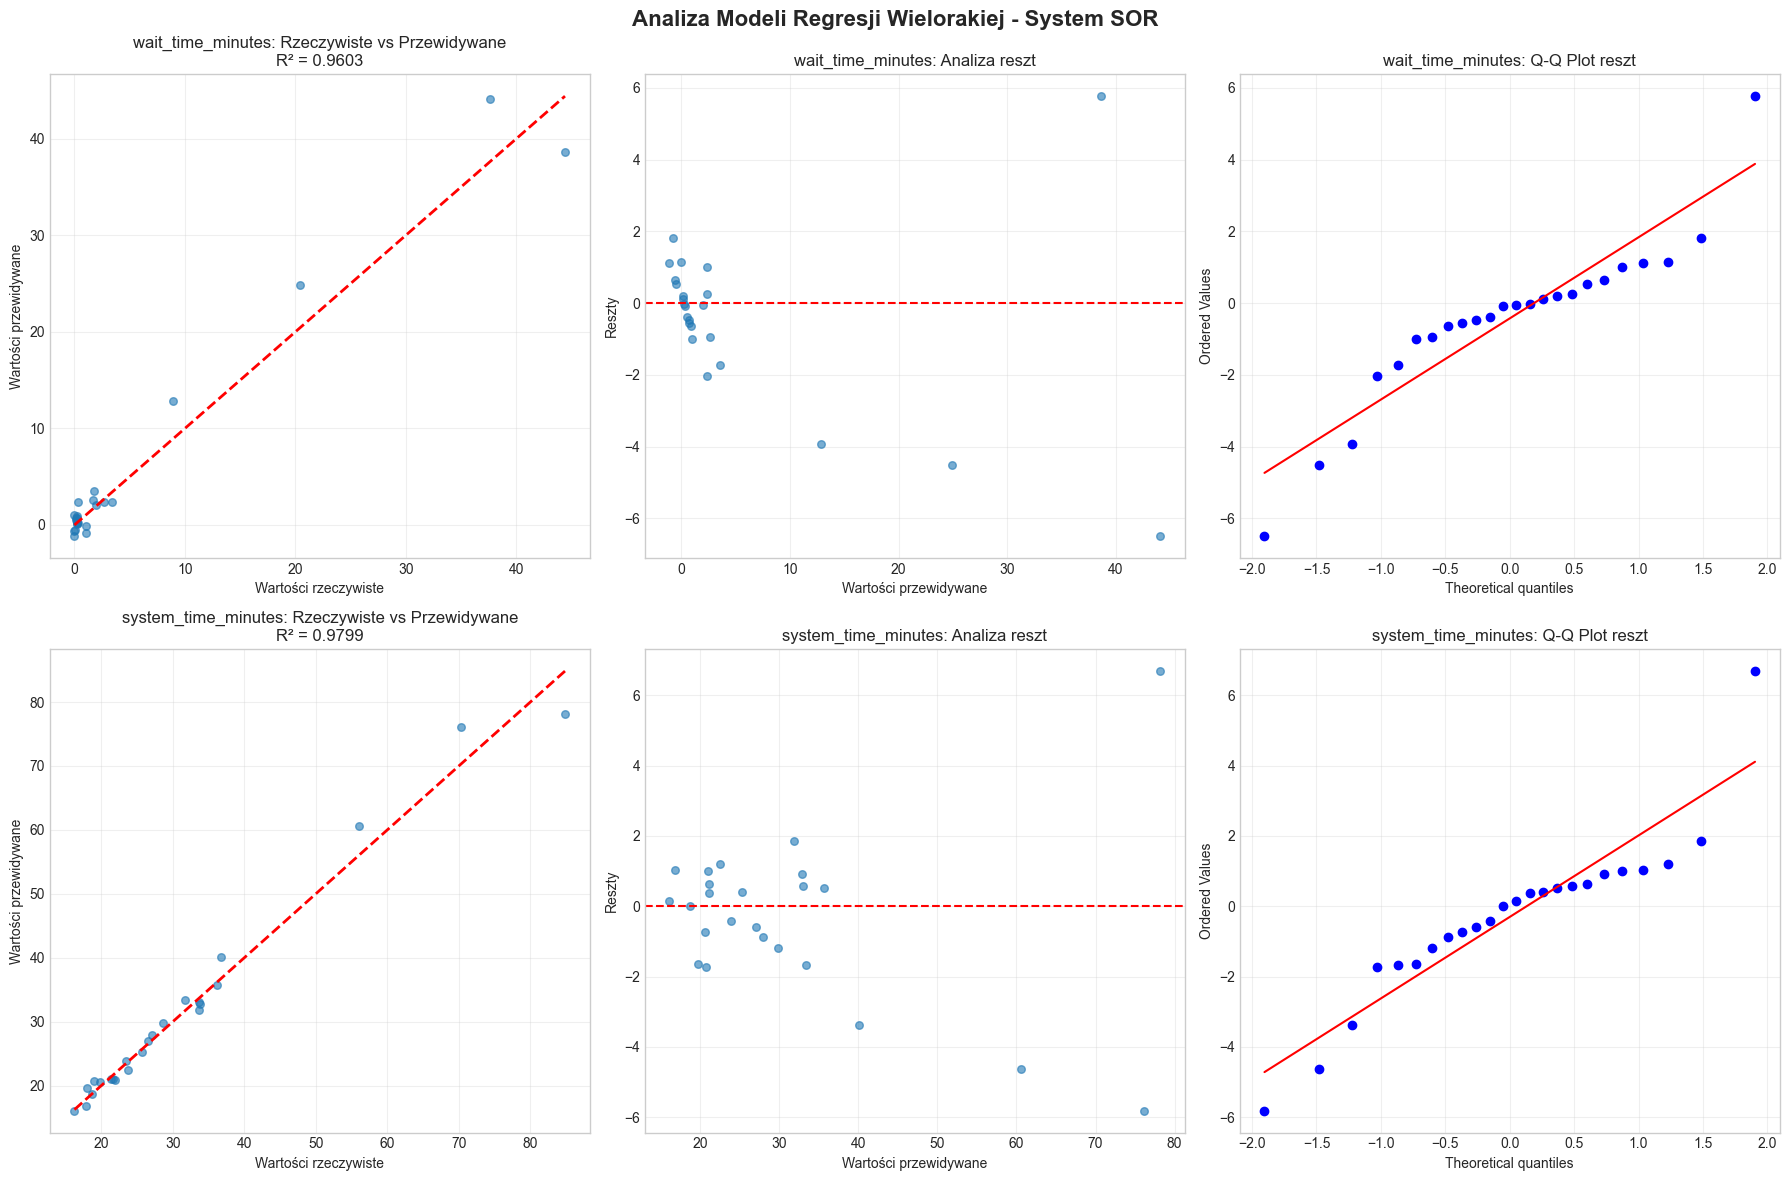

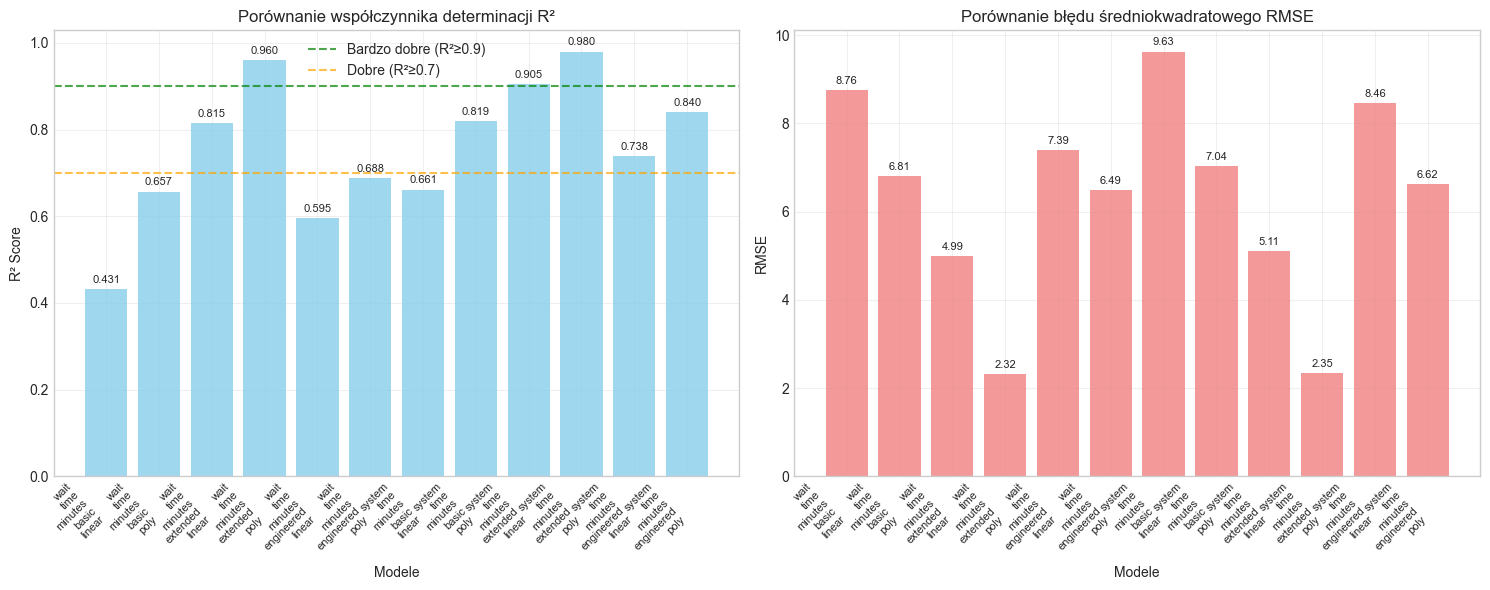

In [475]:
# Wykresy analizujące wyniki regresji
analyzer.plot_regression_results()

In [476]:
# Analiza wpływu poszczególnych parametrów na metryki wydajności
analyzer.feature_importance_analysis()


🔍 ANALIZA WAŻNOŚCI CECH

📊 Analiza dla: wait_time_minutes
------------------------------
Wyraz wolny (intercept): -106.3630

Współczynniki regresji:
  utilization         :  97.3594
  rho                 :  97.3594
  lambda              : -20.9676
  mu                  :  19.5859
  c                   :  13.8376

Interpretacja (przy założeniu ceteris paribus):
  • Wzrost utilization o 1 jednostkę zwiększa wait_time_minutes o 97.3594
  • Wzrost rho o 1 jednostkę zwiększa wait_time_minutes o 97.3594
  • Wzrost lambda o 1 jednostkę zmniejsza wait_time_minutes o 20.9676

📊 Analiza dla: system_time_minutes
------------------------------
Wyraz wolny (intercept): -58.9459

Współczynniki regresji:
  utilization         : 102.3772
  rho                 : 102.3772
  lambda              : -22.6500
  c                   :  14.9028
  mu                  :   9.6468

Interpretacja (przy założeniu ceteris paribus):
  • Wzrost utilization o 1 jednostkę zwiększa system_time_minutes o 102.3772
  • Wzros

### 7. Funkcja przewidywania wydajności

In [477]:
def predict_performance(analyzer, lambda_new, mu_new, c_new):
    """
    Przewiduje metryki wydajności dla nowych parametrów
    """
    print(f"\n🔮 PRZEWIDYWANIE WYDAJNOŚCI SYSTEMU")
    print("=" * 50)
    print(f"Parametry: λ={lambda_new}, μ={mu_new}, c={c_new}")
    
    # Sprawdź stabilność
    rho = lambda_new / (c_new * mu_new)
    if rho >= 1:
        print("⚠️  UWAGA: System niestabilny (ρ ≥ 1)!")
        return
    
    # Przygotuj dane wejściowe
    new_data = pd.DataFrame({
        'lambda': [lambda_new],
        'mu': [mu_new], 
        'c': [c_new],
        'rho': [rho],
        'utilization': [rho],
        'arrival_rate_per_doctor': [lambda_new / c_new],
        'service_capacity': [c_new * mu_new]
    })
    
    # Przewidywania z najlepszych modeli
    predictions = {}
    
    for target in ['wait_time_minutes', 'system_time_minutes']:
        best_r2 = -np.inf
        best_prediction = None
        best_model_name = None
        
        for key, model_data in analyzer.models.items():
            if target in key and model_data['metrics']['r2'] > best_r2:
                best_r2 = model_data['metrics']['r2']
                best_model_name = key
                
                try:
                    if 'poly' in key:
                        # Model wielomianowy
                        X_new = model_data['poly_features'].transform(
                            new_data[model_data['features']]
                        )
                        prediction = model_data['model'].predict(X_new)[0]
                    else:
                        # Model liniowy
                        prediction = model_data['model'].predict(
                            new_data[model_data['features']]
                        )[0]
                    
                    best_prediction = prediction
                except Exception as e:
                    continue
        
        predictions[target] = {
            'value': best_prediction,
            'model': best_model_name,
            'r2': best_r2
        }
    
    # Porównaj z wartościami teoretycznymi
    theoretical = calculate_theoretical_values(lambda_new, mu_new, c_new)
    
    print(f"\nWYNIKI PRZEWIDYWAŃ:")
    print("-" * 30)
    print(f"Średni czas oczekiwania:")
    print(f"  • Regresja: {predictions['wait_time_minutes']['value']:.2f} min")
    print(f"  • Teoria:   {theoretical['Wq']*60:.2f} min")
    print(f"  • Model:    {predictions['wait_time_minutes']['model']} (R²={predictions['wait_time_minutes']['r2']:.3f})")
    
    print(f"\nŚredni czas w systemie:")
    print(f"  • Regresja: {predictions['system_time_minutes']['value']:.2f} min") 
    print(f"  • Teoria:   {theoretical['W']*60:.2f} min")
    print(f"  • Model:    {predictions['system_time_minutes']['model']} (R²={predictions['system_time_minutes']['r2']:.3f})")
    
    print(f"\nParametry systemu:")
    print(f"  • Wykorzystanie (ρ): {rho:.3f}")
    print(f"  • Teoretyczna Lq:   {theoretical['Lq']:.2f} pacjentów")
    
    return predictions

# Przykład przewidywania dla nowych parametrów
predict_performance(analyzer, lambda_new=4.5, mu_new=2.2, c_new=3)


🔮 PRZEWIDYWANIE WYDAJNOŚCI SYSTEMU
Parametry: λ=4.5, μ=2.2, c=3

      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.6818
      Wq (średni czas oczekiwania w kolejce): 0.2219 godzin (13.31 minut)
      Lq (średnia liczba pacjentów w kolejce): 0.9985
      W (średni czas w systemie): 0.6764 godzin (40.59 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.1039

WYNIKI PRZEWIDYWAŃ:
------------------------------
Średni czas oczekiwania:
  • Regresja: 20.47 min
  • Teoria:   13.31 min
  • Model:    wait_time_minutes_extended_poly (R²=0.960)

Średni czas w systemie:
  • Regresja: 44.01 min
  • Teoria:   40.59 min
  • Model:    system_time_minutes_extended_poly (R²=0.980)

Parametry systemu:
  • Wykorzystanie (ρ): 0.682
  • Teoretyczna Lq:   1.00 pacjentów


{'wait_time_minutes': {'value': 20.46583616677509,
  'model': 'wait_time_minutes_extended_poly',
  'r2': 0.9602756020050365},
 'system_time_minutes': {'value': 44.011449038361505,
  'model': 'system_time_minutes_extended_poly',
  'r2': 0.979907734554897}}